**Table of contents**<a id='toc0_'></a>    
- [Imports](#toc1_)    
- [Load Data set](#toc2_)    
- [Understanding Data](#toc3_)    
- [Global constants](#toc4_)    
- [Model 1 - Classification](#toc5_)    
  - [Selecting 5 categories and labels](#toc5_1_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Imports](#toc0_)

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.mixture import GaussianMixture
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from matplotlib import pyplot as plt

# <a id='toc2_'></a>[Load Data set](#toc0_)

In [2]:
data = np.load('./DS_Xdata.npy')
labels = np.load('./Ydata.npy')

# <a id='toc3_'></a>[Understanding Data](#toc0_)

In [3]:
print(f"Shape: {data.shape}")
print(f"Sample count: {len(labels)}")
print(f"Unique label: {np.unique(labels)}")

Shape: (2100, 61, 61, 3)
Sample count: 2100
Unique label: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


# <a id='toc4_'></a>[Global constants](#toc0_)

In [4]:
#Value to replicate the random value generation in the file
seeding_constant = 20

#Categories to be selected for classification
category_count = 5

# <a id='toc5_'></a>[Model 1 - Classification](#toc0_)

## <a id='toc5_1_'></a>[Selecting 5 categories and labels](#toc0_)

In [5]:
np.random.seed(seeding_constant)

unique_label_set = set(np.unique(labels))

selected_categories = [np.random.randint(min(unique_label_set), 
                                         max(unique_label_set)) 
                        for _ in range(category_count)
                        ]

selected_data = [] 
selected_labels = [] 

for index, value in enumerate(labels):
    if value[0] in selected_categories:
        selected_data.append(data[index])
        selected_labels.append(value[0])

## Split data to train(fit) and test(predict)

In [6]:
split_list = train_test_split(selected_data,
                              selected_labels,
                              test_size = 0.1,
                              shuffle = True,
                              random_state = seeding_constant                                      
                            )

train_model1_data = split_list[0]
test_model1_data = split_list[1]
train_model1_labels = split_list[2]
test_model1_labels = split_list[3]

## Using LDA clasification

In [7]:
# Reshape each image to a 1D array
num_features = np.prod(train_model1_data[0].shape) 

train_model1_data_reshaped = np.array([x.reshape(num_features) for x in train_model1_data])
test_model1_data_reshaped = np.array([x.reshape(num_features) for x in test_model1_data])

lda= LDA(n_components = 2)
lda.fit(train_model1_data_reshaped, train_model1_labels)

train_model1_data_lda = lda.transform(train_model1_data_reshaped)
test_model1_data_lda = lda.transform(test_model1_data_reshaped)

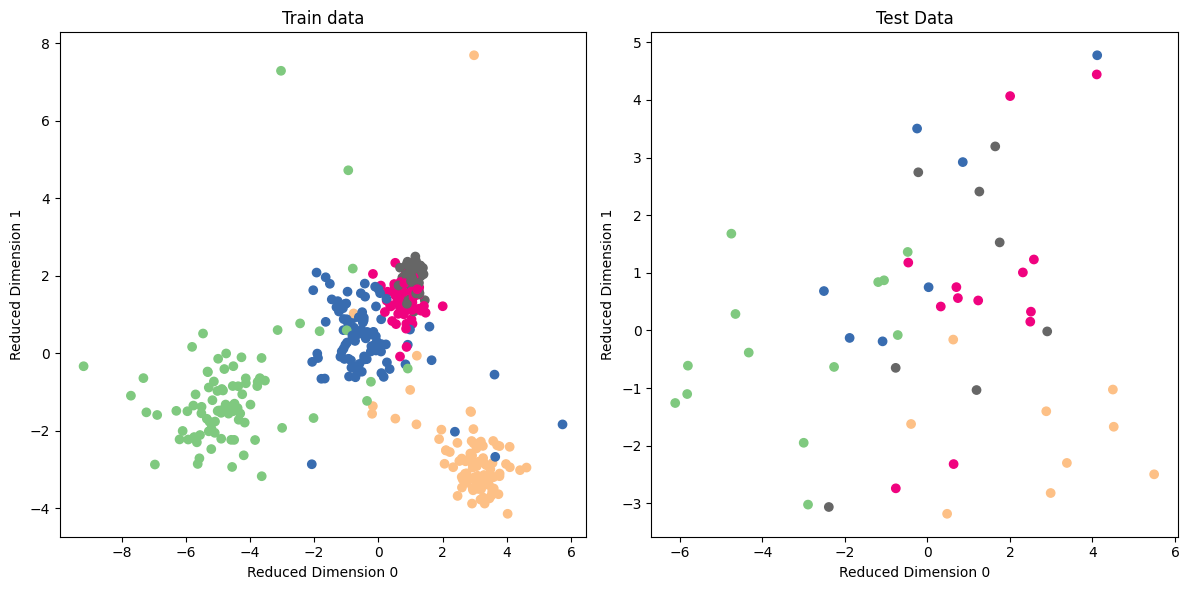

In [8]:
plt.ion()

# Create a figure with multiple subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot ground truth
axs[0].scatter(train_model1_data_lda[:,0], train_model1_data_lda[:,1], c=train_model1_labels, cmap='Accent')
axs[0].set_xlabel("Reduced Dimension 0")
axs[0].set_ylabel("Reduced Dimension 1")
axs[0].set_title("Train data")

# Plot LDA classification
axs[1].scatter(np.array(test_model1_data_lda)[:,0], np.array(test_model1_data_lda)[:,1], c=test_model1_labels, cmap='Accent')
axs[1].set_xlabel("Reduced Dimension 0")
axs[1].set_ylabel("Reduced Dimension 1")
axs[1].set_title("Test Data")

# Layout so plots do not overlap
fig.tight_layout()

plt.show()

## Using GMM clasification

### No hyper param tuning

In [10]:
gmm = GaussianMixture(n_components=5)
gmm.fit(train_model1_data_reshaped)
predicted_labels = gmm.predict(test_model1_data_reshaped)

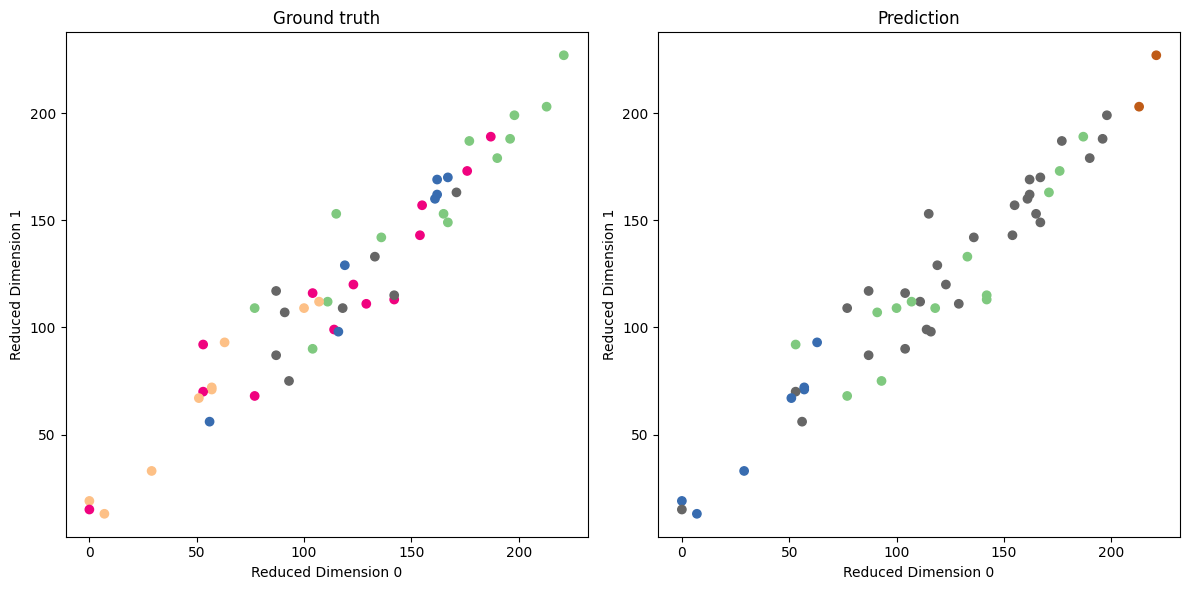

In [11]:
plt.ion()

# Create a figure with multiple subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot ground truth
axs[0].scatter(test_model1_data_reshaped[:,0], test_model1_data_reshaped[:,1], c=test_model1_labels, cmap='Accent')
axs[0].set_xlabel("Reduced Dimension 0")
axs[0].set_ylabel("Reduced Dimension 1")
axs[0].set_title("Ground truth")

# Plot LDA classification
axs[1].scatter(test_model1_data_reshaped[:,0], test_model1_data_reshaped[:,1], c=predicted_labels, cmap='Accent')
axs[1].set_xlabel("Reduced Dimension 0")
axs[1].set_ylabel("Reduced Dimension 1")
axs[1].set_title("Prediction")

# Layout so plots do not overlap
fig.tight_layout()

plt.show()

### With tuning

In [ ]:
gmm = GaussianMixture(n_components=5, init_params='k-means++')
gmm.fit(train_model1_data_reshaped)
predicted_labels = gmm.predict(test_model1_data_reshaped)

In [ ]:
plt.ion()

# Create a figure with multiple subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot ground truth
axs[0].scatter(test_model1_data_reshaped[:,0], test_model1_data_reshaped[:,1], c=test_model1_labels, cmap='Accent')
axs[0].set_xlabel("Reduced Dimension 0")
axs[0].set_ylabel("Reduced Dimension 1")
axs[0].set_title("Ground truth")

# Plot LDA classification
axs[1].scatter(test_model1_data_reshaped[:,0], test_model1_data_reshaped[:,1], c=predicted_labels, cmap='Accent')
axs[1].set_xlabel("Reduced Dimension 0")
axs[1].set_ylabel("Reduced Dimension 1")
axs[1].set_title("Prediction")

# Layout so plots do not overlap
fig.tight_layout()

plt.show()